In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [14]:
train = pd.read_csv('DailyDelhiClimateTrain.csv', parse_dates=['date'], index_col='date')
test  = pd.read_csv('DailyDelhiClimateTest.csv',  parse_dates=['date'], index_col='date')


In [17]:
targets = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
target_names = {
    'meantemp': 'Температура (°C)',
    'humidity': 'Влажность (%)',
    'wind_speed': 'Скорость ветра (м/с)',
    'meanpressure': 'Давление (гПа)'
}

In [18]:
print(f"Обучающий период: {train.index.min().date()} – {train.index.max().date()}  ({len(train)} дней)")
print(f"Тестовый период:   {test.index.min().date()} – {test.index.max().date()}    ({len(test)} дней)")

Обучающий период: 2013-01-01 – 2017-01-01  (1462 дней)
Тестовый период:   2017-01-01 – 2017-04-24    (114 дней)


In [19]:
# степень дифференцирования для стационарности

def find_d(series, max_diff=2):
    for d in range(max_diff+1):
        if d == 0:
            s = series.dropna()
        else:
            s = series.diff(d).dropna()
        pval = adfuller(s)[1]
        if pval <= 0.05:
            return d
    return max_diff


ARIMA для meantemp (Температура (°C))

Степень дифференцирования d = 1
R² = -1.8285


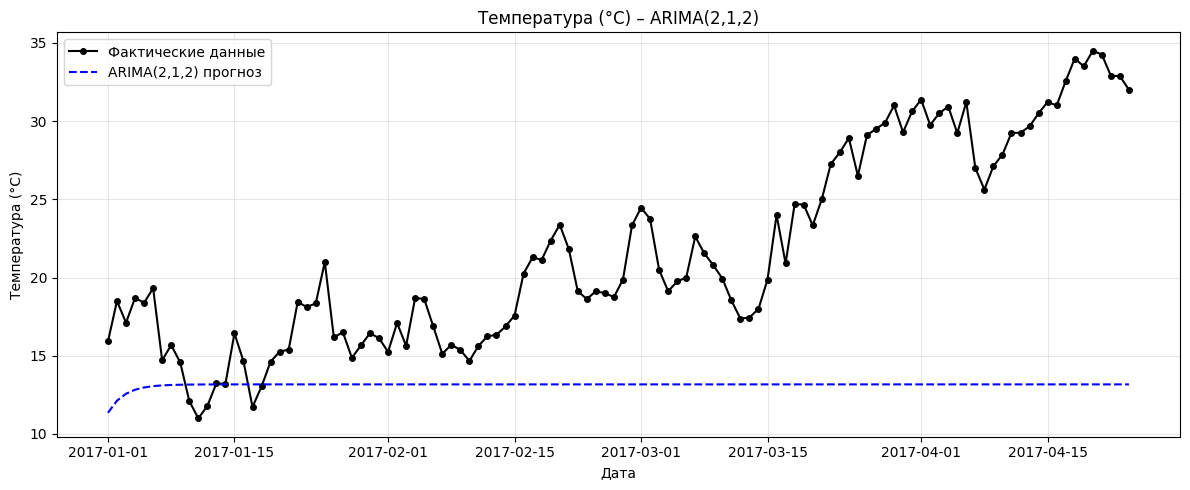


ARIMA для humidity (Влажность (%))

Степень дифференцирования d = 0
R² = 0.0636


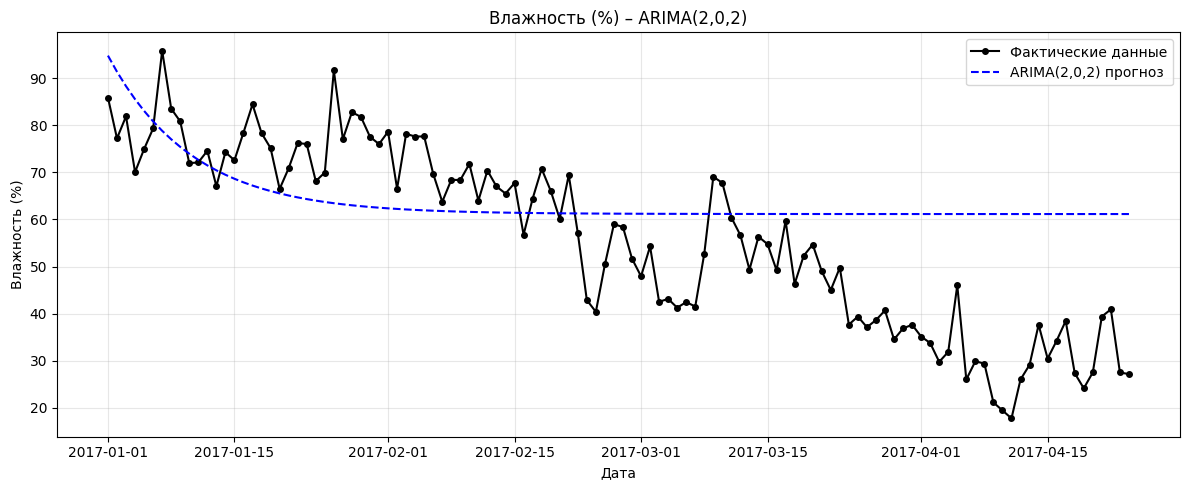


ARIMA для wind_speed (Скорость ветра (м/с))

Степень дифференцирования d = 0
R² = -0.1216


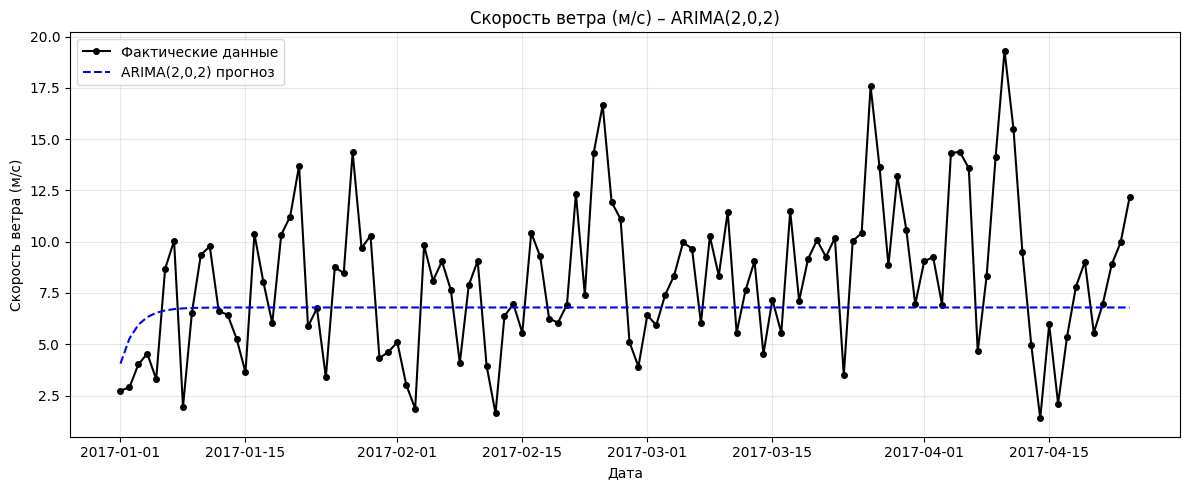


ARIMA для meanpressure (Давление (гПа))

Степень дифференцирования d = 0
R² = -0.0064


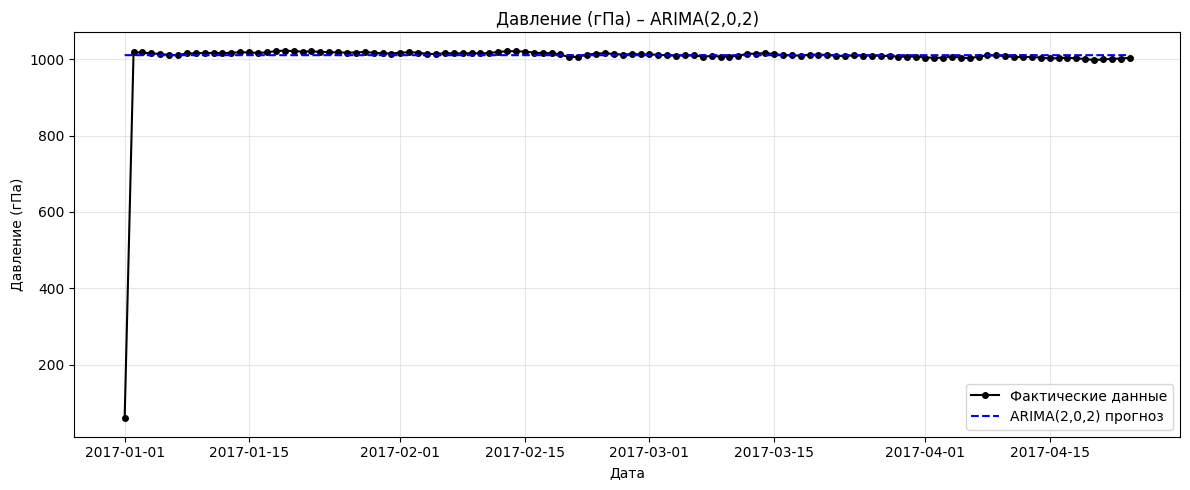

In [39]:
#ARIMA

for target in targets:
    print(f"\nARIMA для {target} ({target_names[target]})\n")
    y_train = train[target]
    y_test = test[target]
    d = find_d(y_train)
    print(f"Степень дифференцирования d = {d}")

    model = ARIMA(y_train, order=(1, d, 1))
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(y_test))
    forecast.index = y_test.index
    r2 = r2_score(y_test, forecast)
    print(f"R² = {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, 'ko-', label='Фактические данные', markersize=4)
    plt.plot(forecast.index, forecast.values, 'b--', label=f'ARIMA(2,{d},2) прогноз')
    plt.title(f'{target_names[target]} – ARIMA(2,{d},2)')
    plt.xlabel('Дата')
    plt.ylabel(target_names[target])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


ARIMAX для meantemp (Температура (°C))n
Степень дифференцирования d = 1
Внешние регрессоры: humidity, wind_speed, meanpressure
R² = 0.0759


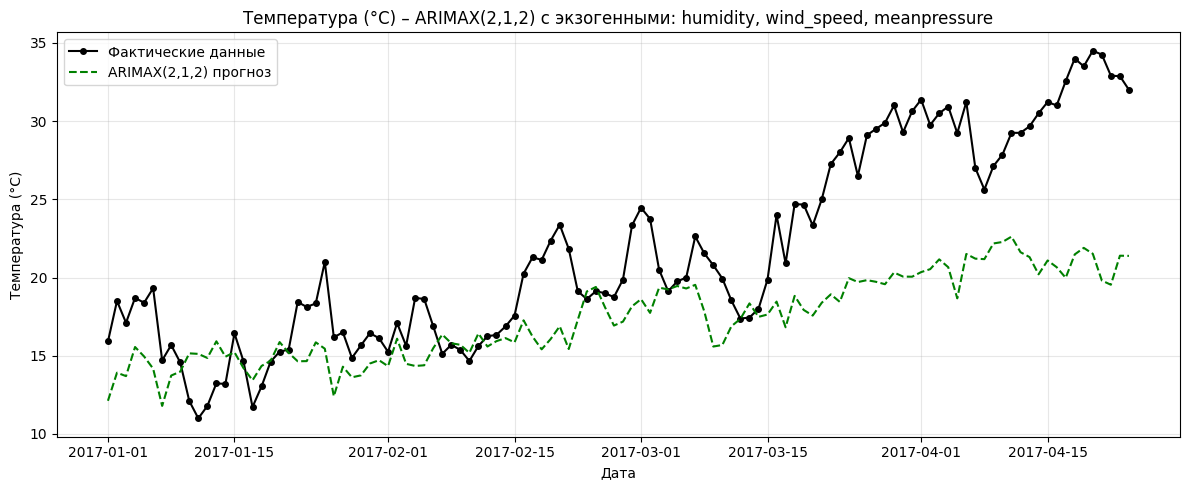


ARIMAX для humidity (Влажность (%))n
Степень дифференцирования d = 0
Внешние регрессоры: meantemp, wind_speed, meanpressure
R² = 0.6615


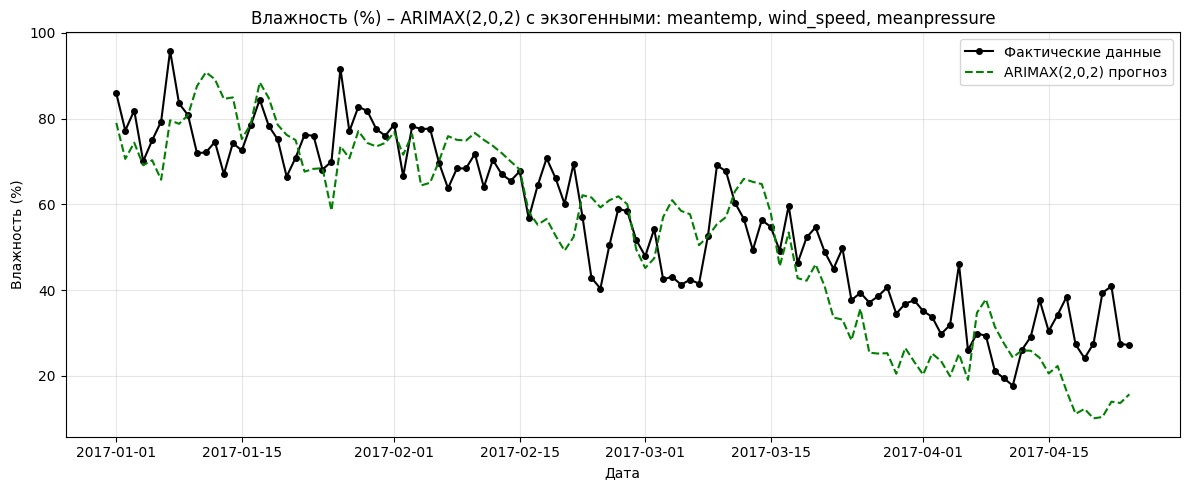


ARIMAX для wind_speed (Скорость ветра (м/с))n
Степень дифференцирования d = 0
Внешние регрессоры: meantemp, humidity, meanpressure
R² = -0.0986


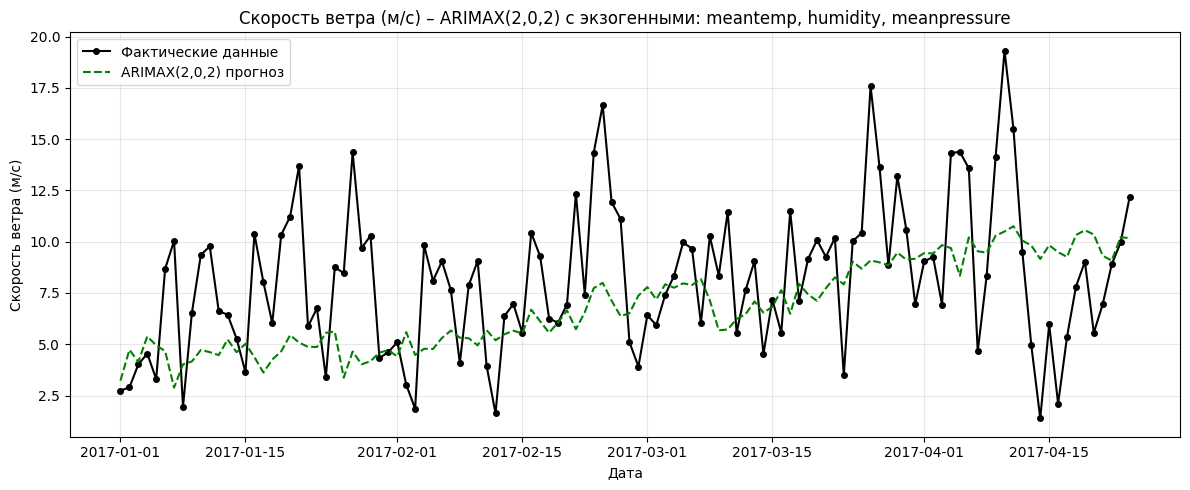


ARIMAX для meanpressure (Давление (гПа))n
Степень дифференцирования d = 0
Внешние регрессоры: meantemp, humidity, wind_speed
R² = -0.0206


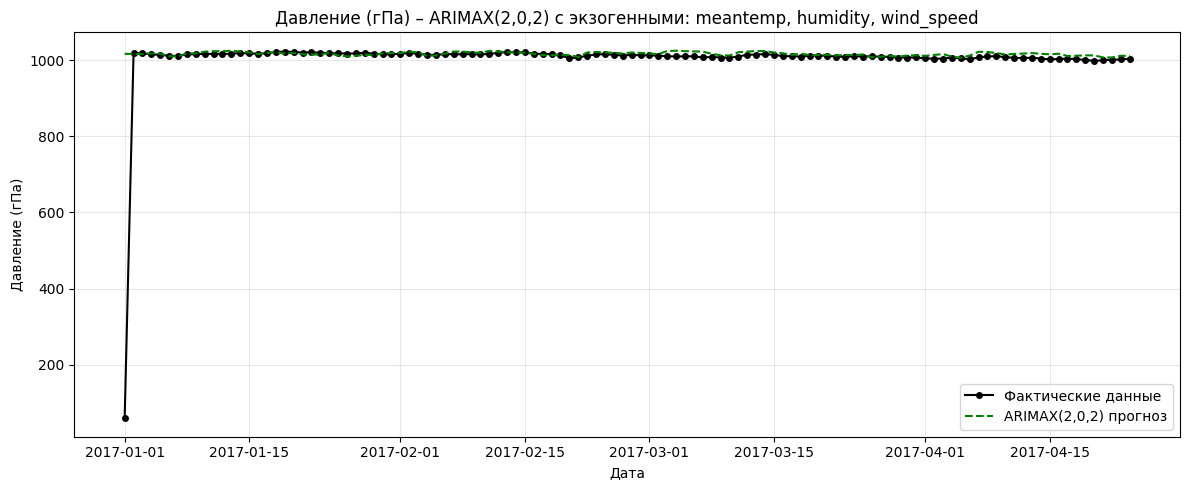

In [43]:
# ARIMAX

for target in targets:
    print(f"\nARIMAX для {target} ({target_names[target]})n")
    y_train = train[target]
    y_test = test[target]
    d = find_d(y_train)
    print(f"Степень дифференцирования d = {d}")

    # Экзогенные переменные – все, кроме текущей
    exog_vars = [c for c in train.columns if c != target]
    X_train = train[exog_vars]
    X_test = test[exog_vars]
    print(f"Внешние регрессоры: {', '.join(exog_vars)}")

    model = ARIMA(y_train, exog=X_train, order=(2, d, 2))
    fitted = model.fit()
    forecast = fitted.forecast(steps=len(y_test), exog=X_test)
    forecast.index = y_test.index
    r2 = r2_score(y_test, forecast)
    print(f"R² = {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, 'ko-', label='Фактические данные', markersize=4)
    plt.plot(forecast.index, forecast.values, 'g--', label=f'ARIMAX(2,{d},2) прогноз')
    plt.title(f'{target_names[target]} – ARIMAX(2,{d},2) с экзогенными: {", ".join(exog_vars)}')
    plt.xlabel('Дата')
    plt.ylabel(target_names[target])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


SARIMA для meantemp (Температура (°C))n
Степень дифференцирования d = 1
Сезонный период s = 7
R² = -1.8235


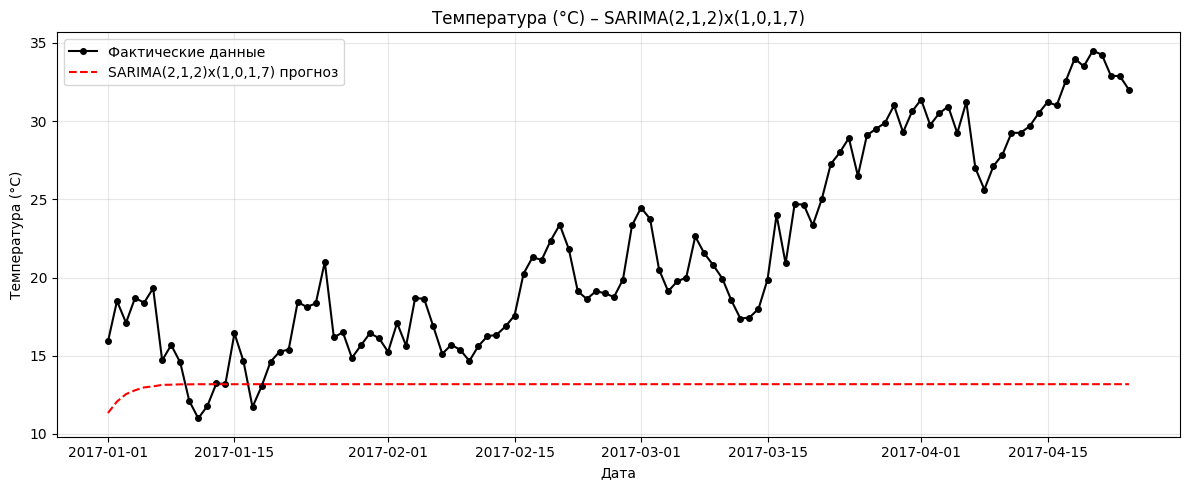


SARIMA для humidity (Влажность (%))n
Степень дифференцирования d = 0
Сезонный период s = 7
R² = -1.4382


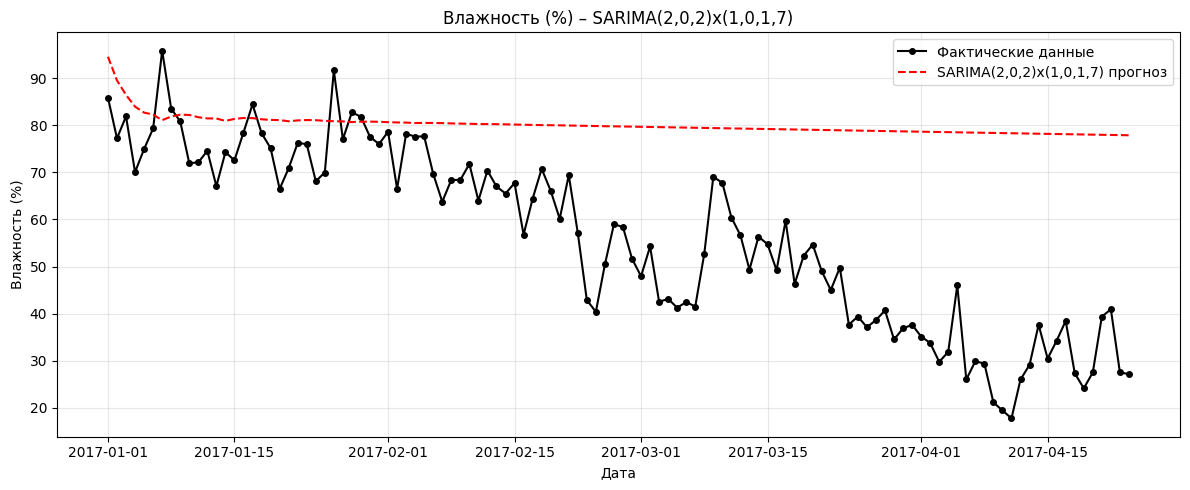


SARIMA для wind_speed (Скорость ветра (м/с))n
Степень дифференцирования d = 0
Сезонный период s = 7
R² = -0.4556


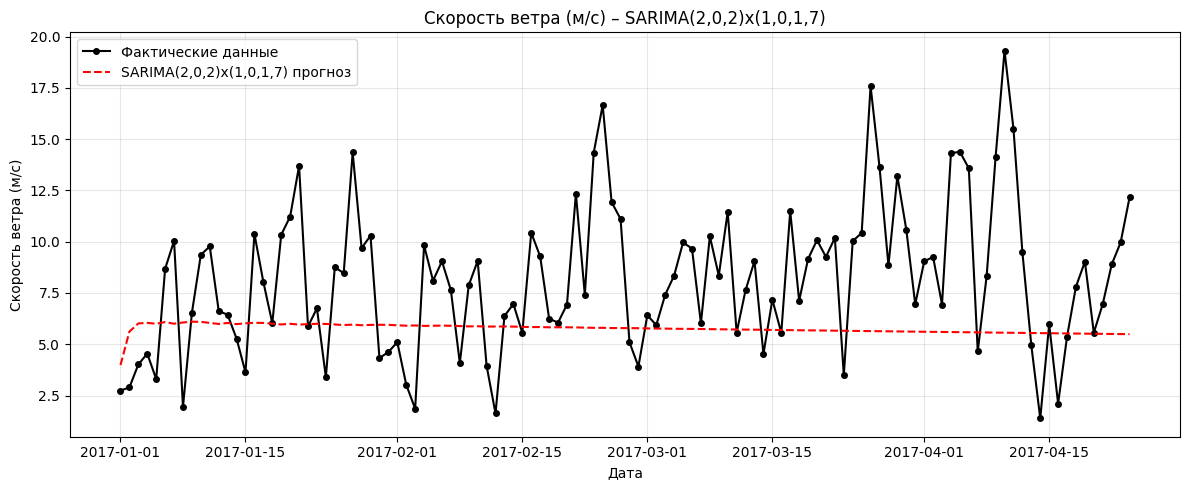


SARIMA для meanpressure (Давление (гПа))n
Степень дифференцирования d = 0
Сезонный период s = 7
R² = -0.0988


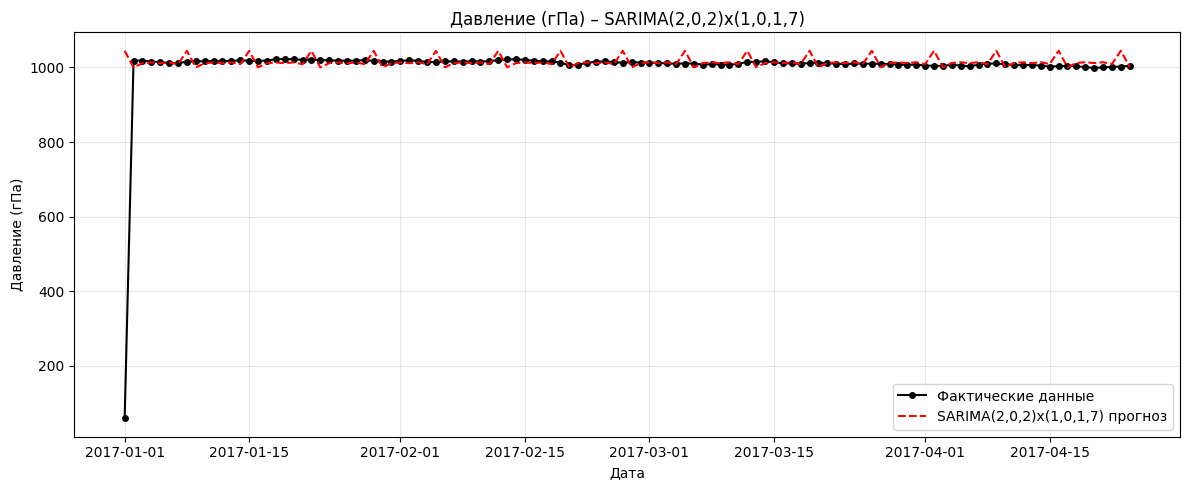

In [45]:
# SARIMA

seasonal_period = 7

for target in targets:
    print(f"\nSARIMA для {target} ({target_names[target]})n")
    y_train = train[target]
    y_test = test[target]
    d = find_d(y_train)
    print(f"Степень дифференцирования d = {d}")
    print(f"Сезонный период s = {seasonal_period}")

    model = SARIMAX(y_train,
                    order=(2, d, 2),
                    seasonal_order=(1, 0, 1, seasonal_period),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(y_test))
    forecast.index = y_test.index
    r2 = r2_score(y_test, forecast)
    print(f"R² = {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, 'ko-', label='Фактические данные', markersize=4)
    plt.plot(forecast.index, forecast.values, 'r--', label=f'SARIMA(2,{d},2)x(1,0,1,{seasonal_period}) прогноз')
    plt.title(f'{target_names[target]} – SARIMA(2,{d},2)x(1,0,1,{seasonal_period})')
    plt.xlabel('Дата')
    plt.ylabel(target_names[target])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


SARIMAX для meantemp (Температура (°C))

Степень дифференцирования d = 1
Сезонный период s = 7 (неделя)
Внешние регрессоры: humidity, wind_speed, meanpressure
R² = 0.1204


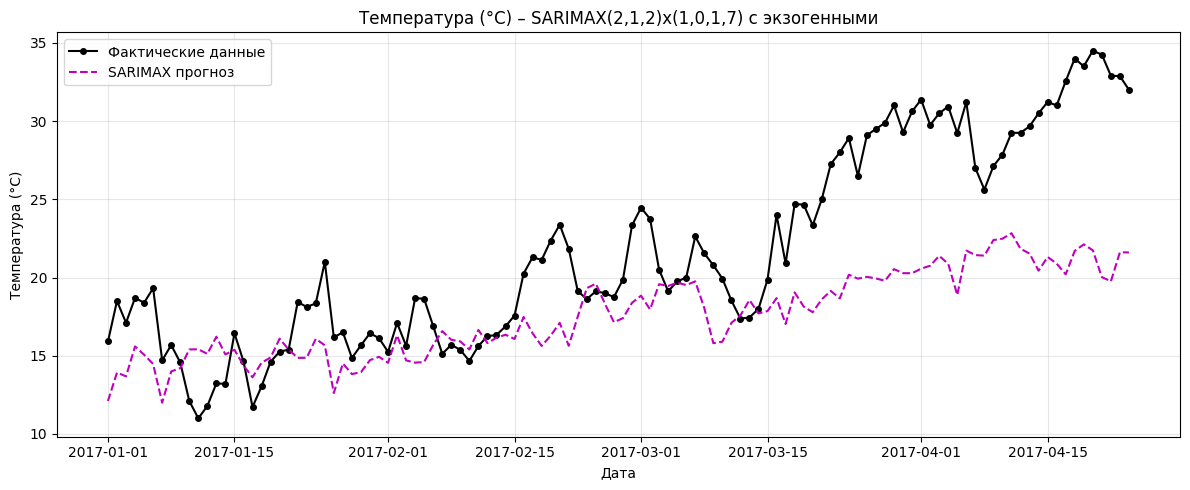


SARIMAX для humidity (Влажность (%))

Степень дифференцирования d = 0
Сезонный период s = 7 (неделя)
Внешние регрессоры: meantemp, wind_speed, meanpressure
R² = 0.4134


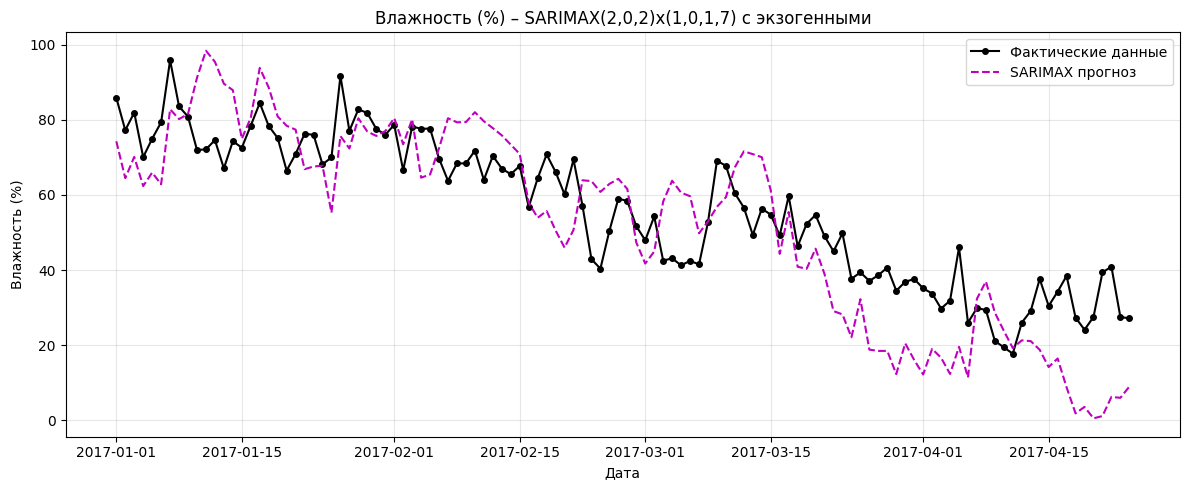


SARIMAX для wind_speed (Скорость ветра (м/с))

Степень дифференцирования d = 0
Сезонный период s = 7 (неделя)
Внешние регрессоры: meantemp, humidity, meanpressure
R² = -1.0188


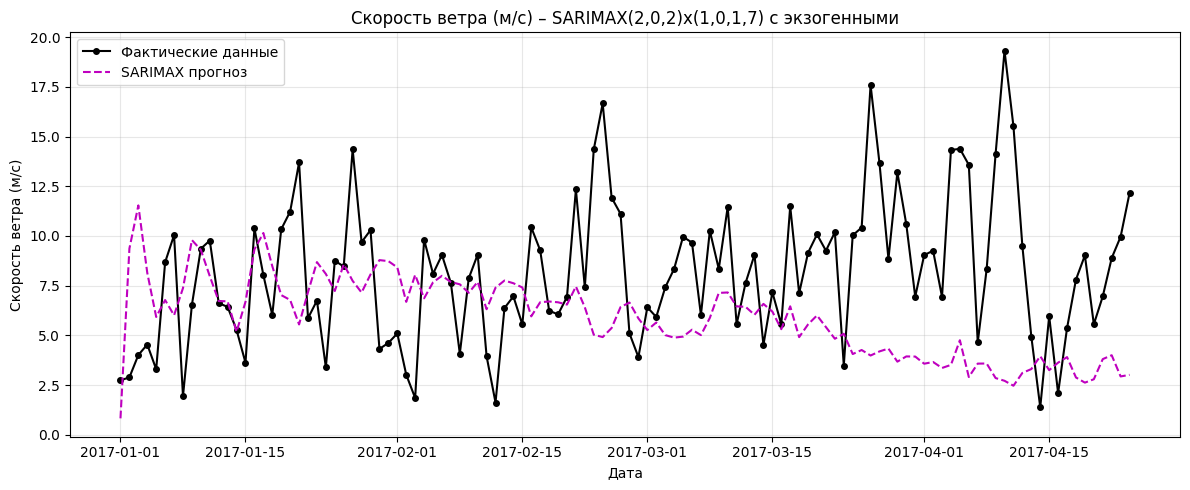


SARIMAX для meanpressure (Давление (гПа))

Степень дифференцирования d = 0
Сезонный период s = 7 (неделя)
Внешние регрессоры: meantemp, humidity, wind_speed
R² = -0.4966


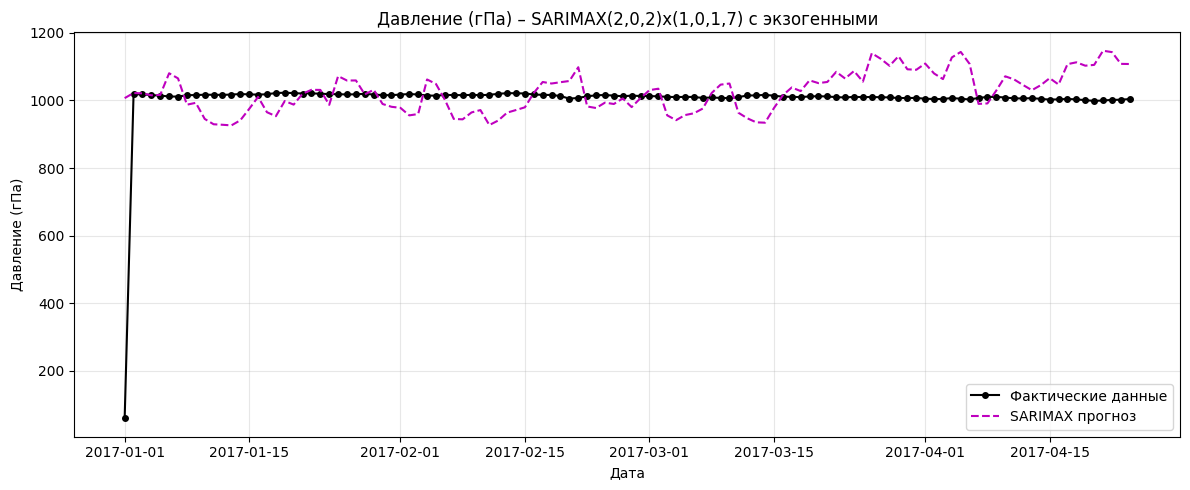

In [48]:
# SARIMAX

seasonal_period = 7

for target in targets:
    print(f"\nSARIMAX для {target} ({target_names[target]})\n")
    y_train = train[target]
    y_test = test[target]
    d = find_d(y_train)
    print(f"Степень дифференцирования d = {d}")
    print(f"Сезонный период s = {seasonal_period} (неделя)")

    exog_vars = [c for c in train.columns if c != target]
    X_train = train[exog_vars]
    X_test = test[exog_vars]
    print(f"Внешние регрессоры: {', '.join(exog_vars)}")

    model = SARIMAX(y_train, exog=X_train,
                    order=(2, d, 1),
                    seasonal_order=(2, 0, 1, seasonal_period),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(y_test), exog=X_test)
    forecast.index = y_test.index
    r2 = r2_score(y_test, forecast)
    print(f"R² = {r2:.4f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, 'ko-', label='Фактические данные', markersize=4)
    plt.plot(forecast.index, forecast.values, 'm--', label='SARIMAX прогноз')
    plt.title(f'{target_names[target]} – SARIMAX(2,{d},2)x(1,0,1,{seasonal_period}) с экзогенными')
    plt.xlabel('Дата')
    plt.ylabel(target_names[target])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



In [ ]:
# ВЫВОД:однозначно лучше SARIMAX и ARIMAX , т.к. они учитывают другие переменные